# LOD MLP Training
**COMP 432 — Adaptive LOD Control**

Pipeline:
1. Load `training_data_labeled.csv`
2. Select and normalize features
3. Split train/validation
4. Define MLP (64 -> 32 -> 16 -> 1, Sigmoid output)
5. Train with MSE loss + Adam
6. Evaluate and plot
7. Export to ONNX for Unity Sentis

In [ ]:
import sys
!{sys.executable} -m pip install torch torchvision pandas scikit-learn matplotlib joblib onnx

In [ ]:
import os
from pathlib import Path

# Set working directory to notebook location
notebook_path = Path(__file__).parent if '__file__' in dir() else Path.cwd()
os.chdir(notebook_path)

print(f'Working directory: {os.getcwd()}')

In [ ]:
from pathlib import Path
import os

plot_dir = Path(r'..' + '\\' + 'ml_pipeline' + '\\' + 'plots' + '\\' + 'Stage_1' + '\\' + 'Train')
plot_dir.mkdir(parents=True, exist_ok=True)
print(f'Plot directory ready: {plot_dir.absolute()}')

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib
import os



print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PyTorch version: 2.5.1+cu121
CUDA available: True
Using device: cuda


## 1. Configuration

In [13]:
from pathlib import Path

# CONFIG
BASE_DIR = Path('../..').resolve()
DATA_DIR = BASE_DIR / 'data' / 'Train_Merged_labeled'
MODEL_DIR = BASE_DIR / 'models' / 'Stage_1'
PLOTS_DIR = BASE_DIR / 'plots' / 'Stage_1' / 'Train'

INPUT_FILE = DATA_DIR / 'training_data_labeled.csv'
MODEL_OUT = MODEL_DIR / 'lod_mlp.onnx'
SCALER_OUT = MODEL_DIR / 'feature_scaler.pkl'

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'BASE_DIR:    {BASE_DIR}')
print(f'DATA_DIR:    {DATA_DIR}')
print(f'MODEL_DIR:   {MODEL_DIR}')
print(f'PLOTS_DIR:   {PLOTS_DIR}')
print(f'INPUT_FILE:  {INPUT_FILE}')
print(f'MODEL_OUT:   {MODEL_OUT}')
print(f'SCALER_OUT:  {SCALER_OUT}')

FEATURE_COLS = [
    'cam_rot_y',              # 0.55
    'screen_coverage',        # 0.54
    'visible_renderer_count', # 0.51
    'cam_pos_y',              # 0.49
    'triangle_count',         # 0.49
    'path_progress',          # 0.48
    'draw_call_estimate',     # 0.48
    'camera_velocity',        # 0.37
    'gpu_frame_time_ms',      # 0.36
    'cam_pos_x',              # 0.34
    'cam_pos_z',              # 0.30
    'fps',                    # 0.21
]

TARGET_COL = 'target_lod_bias'

# MLP architecture
HIDDEN1 = 64
HIDDEN2 = 32
HIDDEN3 = 16

# Training
BATCH_SIZE = 512
EPOCHS = 150
LR = 1e-3
VAL_SPLIT = 0.2
SEED = 42
DIVERSITY_WEIGHT = 0.01

# LOD bias range
BIAS_MIN = 0.25
BIAS_MAX = 2.0

torch.manual_seed(SEED)
np.random.seed(SEED)

BASE_DIR:    C:\Users\Gica\neural-lod\ml_pipeline
DATA_DIR:    C:\Users\Gica\neural-lod\ml_pipeline\data\Train_Merged_labeled
MODEL_DIR:   C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_1
PLOTS_DIR:   C:\Users\Gica\neural-lod\ml_pipeline\plots\Stage_1\Train
INPUT_FILE:  C:\Users\Gica\neural-lod\ml_pipeline\data\Train_Merged_labeled\training_data_labeled.csv
MODEL_OUT:   C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_1\lod_mlp.onnx
SCALER_OUT:  C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_1\feature_scaler.pkl


## 2. Load and Inspect Data

In [14]:
# Load the local processed dataset
df = pd.read_csv(INPUT_FILE)
print(f'Loaded {len(df)} rows, {len(df.columns)} columns')

# Show Target Bias distribution
print(f'\nTarget distribution (LOD Bias):')
print(df[TARGET_COL].value_counts().sort_index())

# Show initial Feature statistics
print(f'\nFeature summary stats:')
display(df[FEATURE_COLS].describe().round(3))


Loaded 60000 rows, 25 columns

Target distribution (LOD Bias):
target_lod_bias
0.25    11305
0.50     8695
0.75    10934
1.25     9066
1.75    10670
2.00     9330
Name: count, dtype: int64

Feature summary stats:


,cam_rot_y,screen_coverage,visible_renderer_count,cam_pos_y,triangle_count,path_progress,draw_call_estimate,camera_velocity,gpu_frame_time_ms,cam_pos_x,cam_pos_z,fps
count,60000.000,60000.000,60000.000,60000.000,60000.000,60000.000,60000.000,60000.000,60000.000,60000.000,60000.000,60000.000
mean,106.648,0.012,7904.246,3.944,332282.440,2.136,2388.281,1.748,4.397,15.900,5.957,65.934
std,91.228,0.011,6564.554,2.438,240615.235,1.882,1802.246,1.250,0.511,17.388,24.010,18.013
min,0.430,0.000,0.000,1.350,5535.000,0.035,103.000,0.000,2.152,-26.120,-58.350,22.160
25%,32.890,0.002,3224.000,2.100,164264.000,0.681,1010.000,0.500,4.107,1.790,-11.780,59.900
50%,89.390,0.009,5157.000,2.730,244900.500,1.211,1803.000,0.501,4.395,24.450,12.875,60.040
75%,182.382,0.020,11025.250,5.940,417458.000,3.726,3093.000,3.000,4.708,28.180,28.070,60.380
max,359.880,0.038,29570.000,8.560,1322892.000,6.216,9783.000,3.010,7.031,52.990,31.200,278.310


## 3. Preprocessing

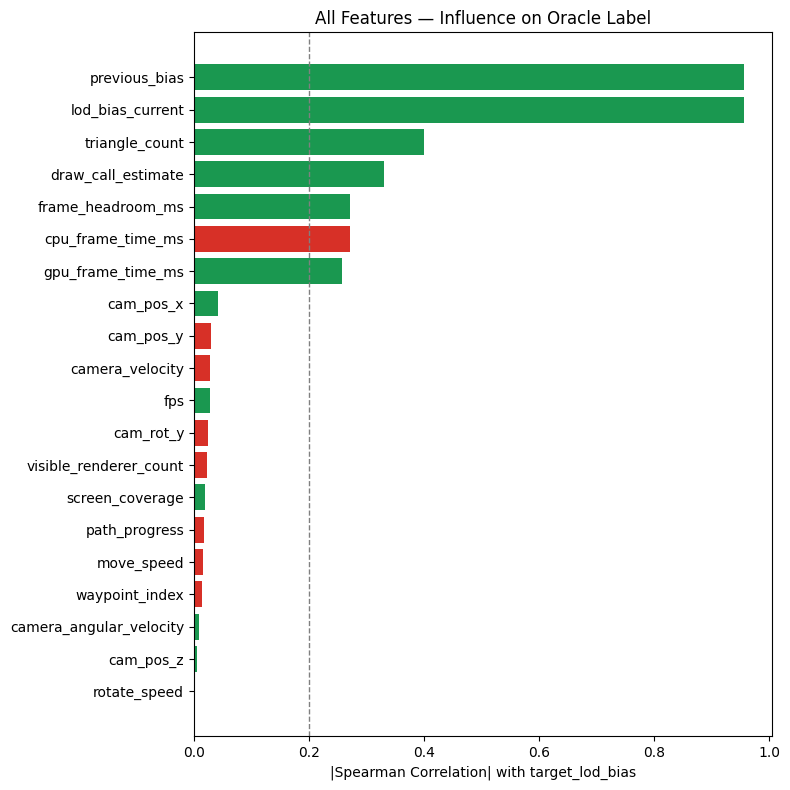

  lod_bias_current               +0.9566  (+ bias)
  previous_bias                  +0.9566  (+ bias)
  triangle_count                 +0.3990  (+ bias)
  draw_call_estimate             +0.3302  (+ bias)
  cpu_frame_time_ms              -0.2716  (- bias)
  frame_headroom_ms              +0.2716  (+ bias)
  gpu_frame_time_ms              +0.2568  (+ bias)
  cam_pos_x                      +0.0413  (+ bias)
  cam_pos_y                      -0.0293  (- bias)
  camera_velocity                -0.0282  (- bias)
  fps                            +0.0272  (+ bias)
  cam_rot_y                      -0.0239  (- bias)
  visible_renderer_count         -0.0233  (- bias)
  screen_coverage                +0.0199  (+ bias)
  path_progress                  -0.0167  (- bias)
  move_speed                     -0.0165  (- bias)
  waypoint_index                 -0.0147  (- bias)
  camera_angular_velocity        +0.0092  (+ bias)
  cam_pos_z                      +0.0052  (+ bias)
  rotate_speed                 

In [15]:
FEATURE_COLS = [
    'cpu_frame_time_ms', 'gpu_frame_time_ms', 'triangle_count',
    'camera_velocity', 'camera_angular_velocity', 'visible_renderer_count',
    'draw_call_estimate', 'frame_headroom_ms', 'screen_coverage',
    'lod_bias_current', 'fps', 'previous_bias',
    'cam_pos_x', 'cam_pos_y', 'cam_pos_z', 'cam_rot_y',
    'path_progress', 'waypoint_index', 'move_speed', 'rotate_speed'
]

corr = df[FEATURE_COLS + [TARGET_COL]].corr(method='spearman')[TARGET_COL].drop(TARGET_COL)
corr_sorted = corr.abs().sort_values(ascending=True)
colors = ['#d73027' if corr[f] < 0 else '#1a9850' for f in corr_sorted.index]

plt.figure(figsize=(8, 8))
plt.barh(corr_sorted.index, corr_sorted.values, color=colors)
plt.axvline(x=0.2, color='gray', linestyle='--', linewidth=1)
plt.xlabel('|Spearman Correlation| with target_lod_bias')
plt.title('All Features — Influence on Oracle Label')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_influence_all.png', dpi=150)
plt.show()

for f in corr.abs().sort_values(ascending=False).index:
    direction = "+ bias" if corr[f] > 0 else "- bias"
    print(f"  {f:<30} {corr[f]:+.4f}  ({direction})")

In [16]:
# Drop rows with NaN in features or target
df = df.dropna(subset=FEATURE_COLS + [TARGET_COL])
print(f'Rows after dropna: {len(df)}')

X     = df[FEATURE_COLS].values.astype(np.float32)
y_raw = df[TARGET_COL].values.astype(np.float32)

#  Label diagnostic
print(f'\nRaw target_lod_bias stats:')
print(f'  min={y_raw.min():.4f}  max={y_raw.max():.4f}  mean={y_raw.mean():.4f}  std={y_raw.std():.4f}')
print(f'  unique values: {len(np.unique(y_raw.round(4)))}')

# Normalize target to [0, 1] for Sigmoid output
y = (y_raw - BIAS_MIN) / (BIAS_MAX - BIAS_MIN)
print(f'\nNormalized target range: [{y.min():.4f}, {y.max():.4f}]')
print(f'Normalized target std:   {y.std():.4f}  (< 0.05 = collapse risk)')

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)
joblib.dump(scaler, SCALER_OUT)
assert os.path.exists(SCALER_OUT), f'Scaler not saved: {SCALER_OUT}'
print(f'Scaler saved to {SCALER_OUT}')

#  Feature variance diagnostic
print(f'\nFeature std after scaling (should all be ~1.0):')
for name, std in zip(FEATURE_COLS, X.std(axis=0)):
    flag = '  <-- LOW VARIANCE' if std < 0.5 else ''
    print(f'  {name:<30} std={std:.4f}{flag}')

# Split off 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)
# Split remaining into 80% train / 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, shuffle=True
)

print(f'\nTrain: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')


Rows after dropna: 60000

Raw target_lod_bias stats:
  min=0.2500  max=2.0000  mean=1.0673  std=0.6435
  unique values: 6

Normalized target range: [0.0000, 1.0000]
Normalized target std:   0.3677  (< 0.05 = collapse risk)
Scaler saved to C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_1\feature_scaler.pkl

Feature std after scaling (should all be ~1.0):
  cpu_frame_time_ms              std=1.0000
  gpu_frame_time_ms              std=1.0000
  triangle_count                 std=1.0000
  camera_velocity                std=1.0000
  camera_angular_velocity        std=1.0000
  visible_renderer_count         std=1.0000
  draw_call_estimate             std=1.0000
  frame_headroom_ms              std=1.0000
  screen_coverage                std=1.0000
  lod_bias_current               std=1.0000
  fps                            std=1.0000
  previous_bias                  std=1.0000
  cam_pos_x                      std=1.0000
  cam_pos_y                      std=1.0000
  cam_pos_z              

## 4. Dataset and DataLoader

In [17]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t,   y_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 75 | Val batches: 19


## 5. Model Definition
Architecture from project docs: Input -> 64 (ReLU) -> 32 (ReLU) -> 1 (Sigmoid)

In [18]:
class LODPredictor(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, hidden3=16):
        super(LODPredictor, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, hidden3),
            nn.ReLU(),
            nn.Linear(hidden3, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

INPUT_DIM = X_train.shape[1]
model     = LODPredictor(INPUT_DIM, HIDDEN1, HIDDEN2, HIDDEN3).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params}')

LODPredictor(
  (layers): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Total parameters: 3969


## 6. Training

In [21]:
def diversity_loss(preds, weight=DIVERSITY_WEIGHT):
    """Penalize low batch prediction variance — prevents mean collapse."""
    pred_std = preds.std()
    if pred_std < 1e-6:
        return torch.tensor(0.0, device=preds.device)
    return -weight * pred_std

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.HuberLoss(delta=0.3)

BEST_MODEL_PATH = BASE_DIR / 'models' / 'Stage_1' / 'best_model.pt'

train_losses     = []
train_div_losses = []
val_losses       = []
best_val_loss    = float('inf')

for epoch in range(EPOCHS):
    # --- train ---
    model.train()
    batch_losses = []
    div_losses   = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        preds = model(X_batch)

        huber = criterion(preds, y_batch)
        div   = diversity_loss(preds)
        loss  = huber + div

        loss.backward()
        optimizer.step()
        batch_losses.append(huber.item())
        div_losses.append(abs(div.item()))

    train_loss = np.mean(batch_losses)
    train_div  = np.mean(div_losses)

    #  validate (no diversity term)
    model.eval()
    with torch.no_grad():
        val_batch_losses = []
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = model(X_batch)
            val_batch_losses.append(criterion(preds, y_batch).item())
        val_loss = np.mean(val_batch_losses)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)

    train_losses.append(train_loss)
    train_div_losses.append(train_div)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | Huber: {train_loss:.6f} | Div: {train_div:.6f} | Val: {val_loss:.6f}')

print('Training complete.')

# Reload best checkpoint
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()
print(f'Loaded best model (val loss: {best_val_loss:.6f})')

# --- test ---
with torch.no_grad():
    X_test_t   = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    y_test_t   = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(DEVICE)
    test_preds = model(X_test_t)
    test_loss  = criterion(test_preds, y_test_t).item()

test_preds_bias  = test_preds.detach().cpu().numpy().flatten() * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_target_bias = y_test * (BIAS_MAX - BIAS_MIN) + BIAS_MIN

test_mae  = np.mean(np.abs(test_preds_bias - test_target_bias))
test_rmse = np.sqrt(np.mean((test_preds_bias - test_target_bias) ** 2))

print(f'\nTest Huber (normalized): {test_loss:.6f}')
print(f'Test MAE   (bias units): {test_mae:.4f}')
print(f'Test RMSE  (bias units): {test_rmse:.4f}')
print(f'\nPredicted bias — min: {test_preds_bias.min():.4f}  max: {test_preds_bias.max():.4f}  std: {test_preds_bias.std():.4f}')
print(f'Oracle  bias  — min: {test_target_bias.min():.4f}  max: {test_target_bias.max():.4f}  std: {test_target_bias.std():.4f}')

Epoch  10/150 | Huber: 0.003607 | Div: 0.003651 | Val: 0.003612
Epoch  20/150 | Huber: 0.003346 | Div: 0.003654 | Val: 0.003786
Epoch  30/150 | Huber: 0.003089 | Div: 0.003658 | Val: 0.003193
Epoch  40/150 | Huber: 0.002814 | Div: 0.003657 | Val: 0.002799
Epoch  50/150 | Huber: 0.002493 | Div: 0.003661 | Val: 0.002490
Epoch  60/150 | Huber: 0.002271 | Div: 0.003662 | Val: 0.002231
Epoch  70/150 | Huber: 0.002026 | Div: 0.003666 | Val: 0.002017
Epoch  80/150 | Huber: 0.001713 | Div: 0.003662 | Val: 0.001838
Epoch  90/150 | Huber: 0.001197 | Div: 0.003662 | Val: 0.001183
Epoch 100/150 | Huber: 0.000983 | Div: 0.003664 | Val: 0.001021
Epoch 110/150 | Huber: 0.000863 | Div: 0.003668 | Val: 0.000903
Epoch 120/150 | Huber: 0.000703 | Div: 0.003668 | Val: 0.000720
Epoch 130/150 | Huber: 0.000670 | Div: 0.003672 | Val: 0.000556
Epoch 140/150 | Huber: 0.000598 | Div: 0.003675 | Val: 0.000617
Epoch 150/150 | Huber: 0.000512 | Div: 0.003678 | Val: 0.000462
Training complete.
Loaded best model (va

C:\Users\Gica\AppData\Local\Temp\ipykernel_20748\1870825335.py:64: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(BEST_MODEL_PATH, map_locati

## 7. Loss Curves

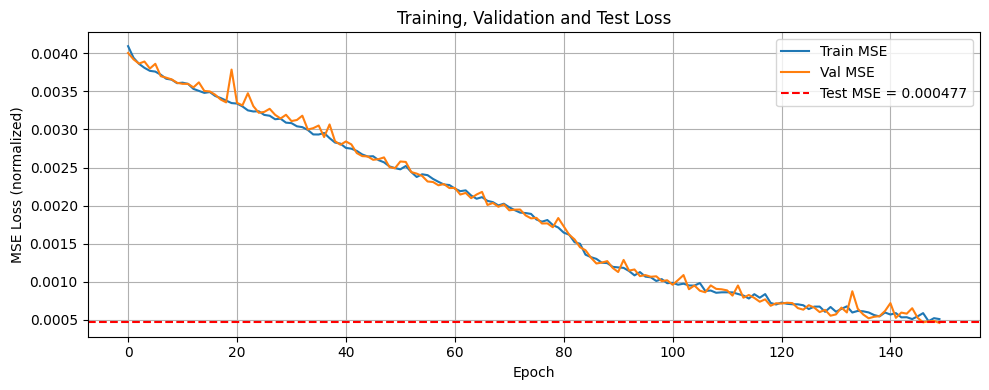

Final Train MSE : 0.000512
Final Val   MSE : 0.000462
Test        MSE : 0.000477
Test        MAE : 0.0343 (bias units)
Test        RMSE: 0.0540 (bias units)


In [22]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses,   label='Val MSE')
plt.axhline(y=test_loss, color='red', linestyle='--', label=f'Test MSE = {test_loss:.6f}')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Training, Validation and Test Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'loss_curve.png', dpi=150)

plt.show()

print(f'Final Train MSE : {train_losses[-1]:.6f}')
print(f'Final Val   MSE : {val_losses[-1]:.6f}')
print(f'Test        MSE : {test_loss:.6f}')
print(f'Test        MAE : {test_mae:.4f} (bias units)')
print(f'Test        RMSE: {test_rmse:.4f} (bias units)')

## 8. Evaluation — Denormalized Predictions



Val  MAE: 0.0337 | Val  RMSE: 0.0531
Test MAE: 0.0343 | Test RMSE: 0.0540


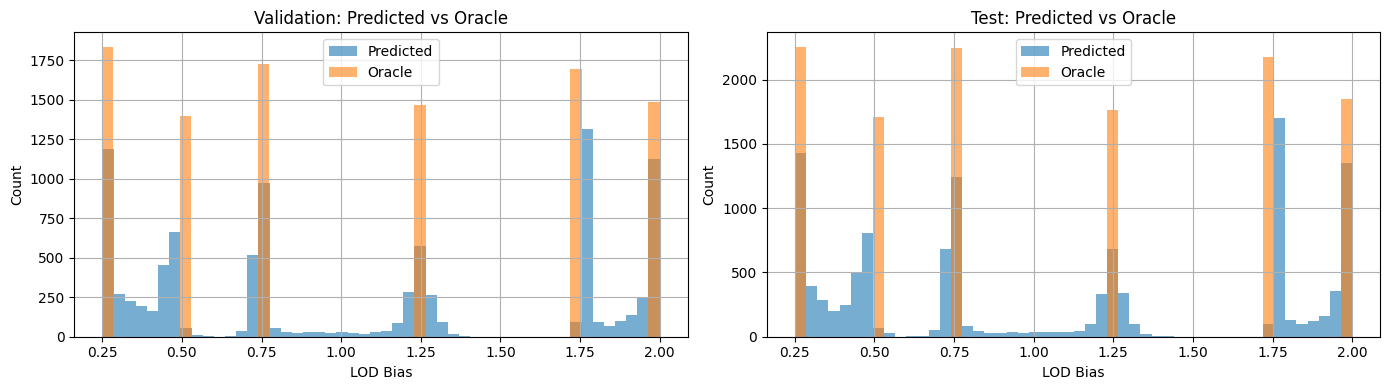

In [23]:
model.eval()
with torch.no_grad():
    preds_norm      = model(X_val_t.to(DEVICE)).cpu().numpy().flatten()
    test_preds_norm = model(torch.tensor(X_test, dtype=torch.float32).to(DEVICE)).cpu().numpy().flatten()

# Denormalize
preds_bias       = preds_norm      * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_preds_bias  = test_preds_norm * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
target_bias      = y_val           * (BIAS_MAX - BIAS_MIN) + BIAS_MIN
test_target_bias = y_test          * (BIAS_MAX - BIAS_MIN) + BIAS_MIN

# Metrics
val_mae  = np.mean(np.abs(preds_bias  - target_bias))
val_rmse = np.sqrt(np.mean((preds_bias  - target_bias) ** 2))
t_mae    = np.mean(np.abs(test_preds_bias - test_target_bias))
t_rmse   = np.sqrt(np.mean((test_preds_bias - test_target_bias) ** 2))

print(f'Val  MAE: {val_mae:.4f} | Val  RMSE: {val_rmse:.4f}')
print(f'Test MAE: {t_mae:.4f} | Test RMSE: {t_rmse:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(preds_bias,  bins=50, alpha=0.6, label='Predicted')
axes[0].hist(target_bias, bins=50, alpha=0.6, label='Oracle')
axes[0].set_title('Validation: Predicted vs Oracle')
axes[0].set_xlabel('LOD Bias')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True)

axes[1].hist(test_preds_bias,  bins=50, alpha=0.6, label='Predicted')
axes[1].hist(test_target_bias, bins=50, alpha=0.6, label='Oracle')
axes[1].set_title('Test: Predicted vs Oracle')
axes[1].set_xlabel('LOD Bias')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'prediction_distribution.png', dpi=150)

plt.show()


checks which input features the trained model depends on. It shuffles one feature at a time and runs inference again. If the model’s loss increases, that feature is important; if not, it has little impact.

Baseline test loss: 0.000477

Permutation Importance (loss increase when feature is shuffled):
  previous_bias                  +0.036469
  lod_bias_current               +0.027067
  cpu_frame_time_ms              +0.009599
  frame_headroom_ms              +0.006173
  move_speed                     +0.005121
  camera_velocity                +0.004292
  path_progress                  +0.002018
  visible_renderer_count         +0.001428
  waypoint_index                 +0.001400
  draw_call_estimate             +0.001249
  triangle_count                 +0.001025
  cam_pos_x                      +0.000972
  cam_pos_y                      +0.000967
  cam_rot_y                      +0.000796
  screen_coverage                +0.000692
  cam_pos_z                      +0.000660
  fps                            +0.000394
  gpu_frame_time_ms              +0.000073  <-- USELESS
  camera_angular_velocity        +0.000064  <-- USELESS
  rotate_speed                   +0.000001  <-- USELESS


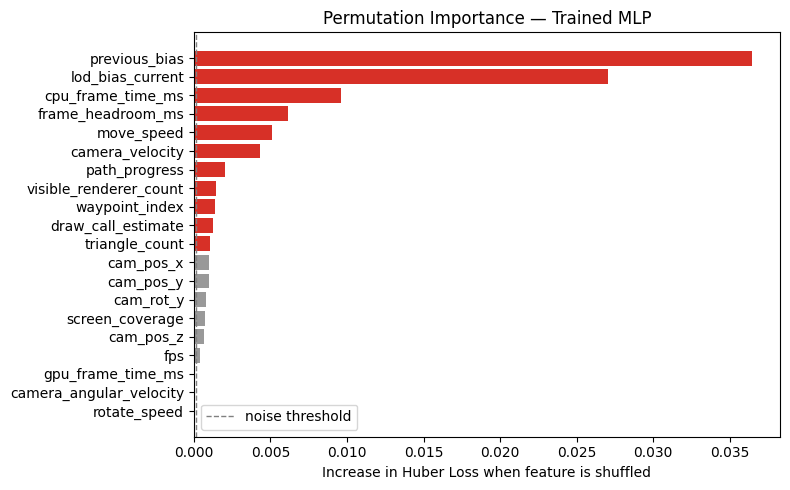

In [24]:
# Permutation Importance   which features actually matter to the trained model
import numpy as np
import matplotlib.pyplot as plt

model.eval()
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(DEVICE)

with torch.no_grad():
    baseline_loss = criterion(model(X_test_t), y_test_t).item()

importance = {}
for i, name in enumerate(FEATURE_COLS):
    X_perm = X_test.copy()
    np.random.shuffle(X_perm[:, i])        # shuffle one column, leave rest intact
    X_perm_t = torch.tensor(X_perm, dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        perm_loss = criterion(model(X_perm_t), y_test_t).item()
    importance[name] = perm_loss - baseline_loss  # higher = more important

importance_sorted = dict(sorted(importance.items(), key=lambda x: x[1]))

print(f"Baseline test loss: {baseline_loss:.6f}")
print(f"\nPermutation Importance (loss increase when feature is shuffled):")
for name, delta in sorted(importance.items(), key=lambda x: x[1], reverse=True):
    flag = "  <-- USELESS" if delta < 0.0001 else ""
    print(f"  {name:<30} +{delta:.6f}{flag}")

# Plot
colors = ['#d73027' if v > 0.001 else '#999999' for v in importance_sorted.values()]
plt.figure(figsize=(8, 5))
plt.barh(list(importance_sorted.keys()), list(importance_sorted.values()), color=colors)
plt.axvline(x=0.0001, color='gray', linestyle='--', linewidth=1, label='noise threshold')
plt.xlabel('Increase in Huber Loss when feature is shuffled')
plt.title('Permutation Importance — Trained MLP')
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'permutation_importance.png', dpi=150)

plt.show()

Determines if one of the features is not needed and should be removed all together

In [25]:
# recommend features to drop based on permutation importance
noise_threshold = 0.0001

drop_list = [name for name, delta in importance.items() if delta < noise_threshold]
keep_list = [name for name, delta in importance.items() if delta >= noise_threshold]

print("\n" + "="*50)
print("FEATURE DROP RECOMMENDATION")
print("="*50)

if drop_list:
    print(f"\n  DROP these features from training AND inference ({len(drop_list)}):")
    for name in sorted(drop_list, key=lambda x: importance[x]):
        print(f"    - {name:<30} delta={importance[name]:.6f}  below noise floor")
else:
    print("\n  No features below noise threshold. Keep all.")

print(f"\n  KEEP these features ({len(keep_list)}):")
for name in sorted(keep_list, key=lambda x: importance[x], reverse=True):
    print(f"    + {name:<30} delta={importance[name]:.6f}")

print(f"\n  Feature count: {len(FEATURE_COLS)} --> {len(keep_list)} after dropping")
print("="*50)


FEATURE DROP RECOMMENDATION

  DROP these features from training AND inference (3):
    - rotate_speed                   delta=0.000001  below noise floor
    - camera_angular_velocity        delta=0.000064  below noise floor
    - gpu_frame_time_ms              delta=0.000073  below noise floor

  KEEP these features (17):
    + previous_bias                  delta=0.036469
    + lod_bias_current               delta=0.027067
    + cpu_frame_time_ms              delta=0.009599
    + frame_headroom_ms              delta=0.006173
    + move_speed                     delta=0.005121
    + camera_velocity                delta=0.004292
    + path_progress                  delta=0.002018
    + visible_renderer_count         delta=0.001428
    + waypoint_index                 delta=0.001400
    + draw_call_estimate             delta=0.001249
    + triangle_count                 delta=0.001025
    + cam_pos_x                      delta=0.000972
    + cam_pos_y                      delta=0.0009

## 9. Export to ONNX for Unity Sentis

In [26]:
#!pip install onnxscript onnx
%pip install torch torchvision pandas scikit-learn matplotlib joblib onnx
%pip install onnxscript

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [27]:
model.eval()
model.cpu()

dummy_input = torch.zeros(1, INPUT_DIM, dtype=torch.float32)

torch.onnx.export(
    model,
    dummy_input,
    MODEL_OUT,
    export_params=True,
    opset_version=15,
    input_names=['features'],
    output_names=['lod_bias_normalized'],
    dynamic_axes={
        'features':           {0: 'batch_size'},
        'lod_bias_normalized': {0: 'batch_size'}
    }
)

size_kb = os.path.getsize(MODEL_OUT) / 1024
print(f'ONNX model saved to {MODEL_OUT} ({size_kb:.1f} KB)')
print(f'Input dim: {INPUT_DIM} features')
print(f'Output: normalized bias in [0,1] -> denormalize with BIAS_MIN={BIAS_MIN}, BIAS_MAX={BIAS_MAX}')

ONNX model saved to C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_1\lod_mlp.onnx (16.9 KB)
Input dim: 20 features
Output: normalized bias in [0,1] -> denormalize with BIAS_MIN=0.25, BIAS_MAX=2.0


In [29]:
import onnx

# Load the split model (needs both .onnx and .onnx.data in same folder)
model_onnx = onnx.load(MODEL_OUT, load_external_data=True)

# Save as single self-contained file - no external data
SINGLE_OUT = BASE_DIR / 'models' / 'Stage_1' / 'lod_mlp_single.onnx'

onnx.save_model(
    model_onnx,
    SINGLE_OUT,
    save_as_external_data=False
)

import os
size_kb = os.path.getsize(SINGLE_OUT) / 1024
print(f'Saved single-file ONNX: {SINGLE_OUT} ({size_kb:.1f} KB)')

Saved single-file ONNX: C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_1\lod_mlp_single.onnx (16.9 KB)


### 9b. Export Scaler Constants to JSON

In [31]:
import json, joblib

scaler = joblib.load(SCALER_OUT)

constants = {
    'mean':          scaler.mean_.tolist(),
    'scale':         scaler.scale_.tolist(),
    'feature_names': FEATURE_COLS,
    'bias_min':      BIAS_MIN,
    'bias_max':      BIAS_MAX
}
SCALER_JSON = BASE_DIR / 'models' / 'Stage_1' / 'scaler_constants.json'

with open(SCALER_JSON, 'w') as f:
    json.dump(constants, f, indent=2)

print(f'Saved to {SCALER_JSON}')
print(json.dumps(constants, indent=2))

Saved to C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_1\scaler_constants.json
{
  "mean": [
    17.236344322482744,
    4.397493781411648,
    332282.4397,
    1.748308652406931,
    3.5127006494700908,
    7904.246483333333,
    2388.281466666667,
    -0.5696776516178313,
    0.011962161683615219,
    1.0833333333333333,
    65.93369566510519,
    1.0833333333333333,
    15.900362616746966,
    3.944417531742652,
    5.95651316775782,
    106.64811897724867,
    2.1363132155102367,
    2.6931,
    1.75,
    1.0
  ],
  "scale": [
    4.2510750122855026,
    0.5107840313197152,
    240613.22951353423,
    1.250376699805574,
    14.817560455986944,
    6564.498995421964,
    1802.2310967362598,
    4.251075008616426,
    0.010816966258654819,
    0.716860438920219,
    18.012586537244548,
    0.716860438920219,
    17.388295315248925,
    2.4378889710088747,
    24.010136128389085,
    91.22719959416683,
    1.8820146168069647,
    1.8674347083633205,
    1.25,
    0.5
  ],
  "featu

## 10. Unity Sentis Integration Notes

In `NeuralLODController.cs`, denormalize the output:

```csharp
float normalizedBias = output[0];  // Sigmoid output in [0,1]
float targetBias = normalizedBias * (2.0f - 0.25f) + 0.25f;// BIAS_MIN = 0.25f, BIAS_MAX = 2.0f
```

Feature order for the input tensor must match `FEATURE_COLS` exactly:
```
0  cpu_frame_time_ms
1  gpu_frame_time_ms
2  triangle_count
3  camera_velocity
4  camera_angular_velocity
5  visible_renderer_count
6  draw_call_estimate
7  frame_headroom_ms
8  screen_coverage
9  lod_bias_current
```

Apply scaler mean/std from `feature_scaler.pkl` to each feature before inference:
```csharp
float[] scalerMean = { /* from scaler.mean_ */ };
float[] scalerStd  = { /* from scaler.scale_ */ };
for (int i = 0; i < features.Length; i++)
    features[i] = (features[i] - scalerMean[i]) / scalerStd[i];
```